<a href="https://colab.research.google.com/github/NikhilGeorge01/DeepLearningPractice/blob/main/SatelliteDL(Assignment).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch
import torchvision
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

print("All libraries imported successfully!")


All libraries imported successfully!


In [7]:
from google.colab import drive
drive.mount('/content/drive')







Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
files = [f"{i}.png" for i in range(1, 500)]

with open("/content/file_list.txt", "w") as f:
    for fname in files:
        f.write(fname + "\n")

print("Saved to file_list.txt")

Saved to file_list.txt


In [9]:
# Setup folders
!rm -rf /content/patches
!mkdir -p /content/patches/LR
!mkdir -p /content/patches/HR

import os, random

src_lr = "/content/drive/MyDrive/Satellite_SR_Project/patches/LR"
src_hr = "/content/drive/MyDrive/Satellite_SR_Project/patches/HR"


# Fast copy using shell
!cat /content/file_list.txt | xargs -P 4 -I {} cp "/content/drive/MyDrive/Satellite_SR_Project/patches/LR/{}" /content/patches/LR/
!cat /content/file_list.txt | xargs -P 4 -I {} cp "/content/drive/MyDrive/Satellite_SR_Project/patches/HR/{}" /content/patches/HR/
print(f"Copied  matched files (50%)")

Copied  matched files (50%)


In [4]:
LR_DIR = "/content/patches/LR"
HR_DIR = "/content/patches/HR"

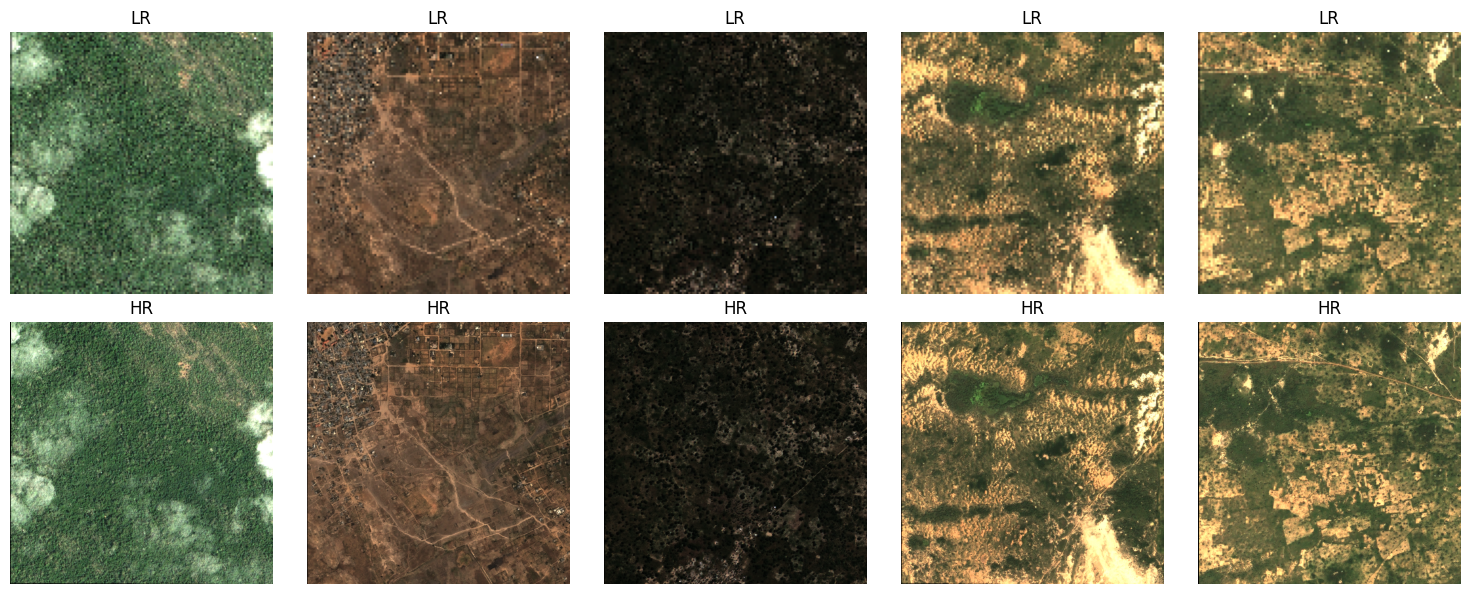

LR Mean: [56.48739584 78.13858688 89.6784384 ]
LR Std: [39.48209354 53.36329602 65.15311603]

HR Mean: [56.4573124  78.1037316  89.68894472]
HR Std: [39.79891037 53.78422196 65.67428145]


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Function to display multiple samples
def show_samples(n=5):
    files = sorted(os.listdir(LR_DIR))[:n]

    plt.figure(figsize=(15, 6))

    for i, fname in enumerate(files):
        lr = cv2.imread(os.path.join(LR_DIR, fname))
        hr = cv2.imread(os.path.join(HR_DIR, fname))

        lr = cv2.cvtColor(lr, cv2.COLOR_BGR2RGB)
        hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)

        plt.subplot(2, n, i+1)
        plt.imshow(lr)
        plt.title("LR")
        plt.axis("off")

        plt.subplot(2, n, i+1+n)
        plt.imshow(hr)
        plt.title("HR")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Show samples
show_samples(5)

# Compute dataset statistics
def compute_stats(sample_size=50):
    files = sorted(os.listdir(LR_DIR))[:sample_size]

    lr_pixels = []
    hr_pixels = []

    for fname in files:
        lr = cv2.imread(os.path.join(LR_DIR, fname))
        hr = cv2.imread(os.path.join(HR_DIR, fname))

        lr_pixels.append(lr.reshape(-1, 3))
        hr_pixels.append(hr.reshape(-1, 3))

    lr_pixels = np.concatenate(lr_pixels, axis=0)
    hr_pixels = np.concatenate(hr_pixels, axis=0)

    print("LR Mean:", lr_pixels.mean(axis=0))
    print("LR Std:", lr_pixels.std(axis=0))

    print("\nHR Mean:", hr_pixels.mean(axis=0))
    print("HR Std:", hr_pixels.std(axis=0))

compute_stats()

In [11]:
# Normalize images to [0,1]

def load_image_pair(fname):
    lr = cv2.imread(os.path.join(LR_DIR, fname))
    hr = cv2.imread(os.path.join(HR_DIR, fname))

    # Convert BGR → RGB and scale to [0,1]
    lr = cv2.cvtColor(lr, cv2.COLOR_BGR2RGB) / 255.0
    hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB) / 255.0

    return lr, hr

# Test normalization
fname = sorted(os.listdir(LR_DIR))[0]
lr, hr = load_image_pair(fname)

print("LR min/max:", lr.min(), lr.max())
print("HR min/max:", hr.min(), hr.max())

LR min/max: 0.03529411764705882 1.0
HR min/max: 0.0 1.0


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

# Prepare small dataset (to keep it fast)
def create_dataset(n_samples=50):
    X = []
    Y = []

    files = sorted(os.listdir(LR_DIR))[:n_samples]

    for fname in files:
        lr, hr = load_image_pair(fname)

        # Resize HR to match LR size (for MLP simplicity)
        hr_resized = cv2.resize(hr, (lr.shape[1], lr.shape[0]))

        X.append(lr.flatten())
        Y.append(hr_resized.flatten())

    X = torch.tensor(X, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)

    return X, Y

X, Y = create_dataset()

print("Input shape:", X.shape)
print("Target shape:", Y.shape)

Input shape: torch.Size([50, 46875])
Target shape: torch.Size([50, 46875])


/tmp/ipykernel_18740/3712297952.py:21: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.tensor(X, dtype=torch.float32)


In [13]:
# Simple MLP model

class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim)
        )

    def forward(self, x):
        return self.model(x)

# Initialize model
input_dim = X.shape[1]
model = MLP(input_dim)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

MLP(
  (model): Sequential(
    (0): Linear(in_features=46875, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=46875, bias=True)
  )
)


In [14]:
# Training loop

epochs = 10

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()

    outputs = model(X)
    loss = criterion(outputs, Y)

    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

Epoch [1/10], Loss: 0.133623
Epoch [2/10], Loss: 4.664231
Epoch [3/10], Loss: 0.266297
Epoch [4/10], Loss: 0.244359
Epoch [5/10], Loss: 0.099573
Epoch [6/10], Loss: 0.072028
Epoch [7/10], Loss: 0.054439
Epoch [8/10], Loss: 0.044471
Epoch [9/10], Loss: 0.037271
Epoch [10/10], Loss: 0.033108


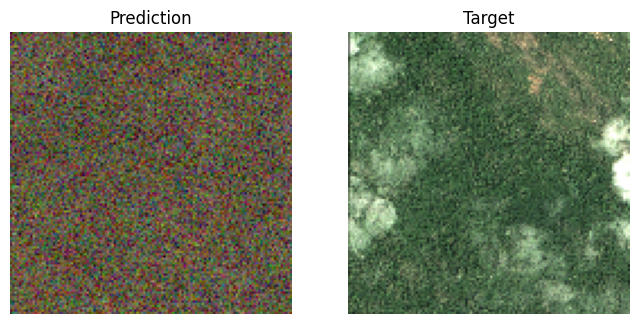

In [15]:
# Visualize predictions

def show_prediction(index=0):
    model.eval()

    with torch.no_grad():
        pred = model(X[index:index+1]).reshape(-1, 3)
        target = Y[index].reshape(-1, 3)

    # reshape to image
    size = int((X.shape[1] // 3) ** 0.5)

    pred_img = pred.numpy().reshape(size, size, 3)
    target_img = target.numpy().reshape(size, size, 3)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(pred_img)
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

    plt.show()

show_prediction(0)

In [16]:
# Prepare dataset for CNN

def create_cnn_dataset(n_samples=50):
    X = []
    Y = []

    files = sorted(os.listdir(LR_DIR))[:n_samples]

    for fname in files:
        lr, hr = load_image_pair(fname)

        # Resize HR to LR size
        hr_resized = cv2.resize(hr, (lr.shape[1], lr.shape[0]))

        # Convert HWC → CHW (PyTorch format)
        lr = np.transpose(lr, (2, 0, 1))
        hr_resized = np.transpose(hr_resized, (2, 0, 1))

        X.append(lr)
        Y.append(hr_resized)

    X = torch.tensor(X, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)

    return X, Y

X_cnn, Y_cnn = create_cnn_dataset()

print("CNN Input shape:", X_cnn.shape)
print("CNN Target shape:", Y_cnn.shape)

CNN Input shape: torch.Size([50, 3, 125, 125])
CNN Target shape: torch.Size([50, 3, 125, 125])


In [17]:
# Simple CNN for reconstruction

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 3, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return self.model(x)

# Initialize
cnn_model = SimpleCNN()

criterion = nn.MSELoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

print(cnn_model)

SimpleCNN(
  (model): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(16, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)


In [18]:
# Training CNN

epochs = 10

for epoch in range(epochs):
    cnn_model.train()

    optimizer.zero_grad()

    outputs = cnn_model(X_cnn)
    loss = criterion(outputs, Y_cnn)

    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

Epoch [1/10], Loss: 0.113189
Epoch [2/10], Loss: 0.109450
Epoch [3/10], Loss: 0.105927
Epoch [4/10], Loss: 0.102682
Epoch [5/10], Loss: 0.099338
Epoch [6/10], Loss: 0.095469
Epoch [7/10], Loss: 0.090897
Epoch [8/10], Loss: 0.085396
Epoch [9/10], Loss: 0.078714
Epoch [10/10], Loss: 0.070583


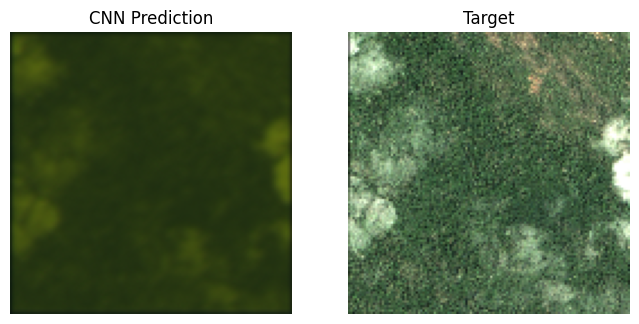

In [19]:
# Visualize CNN prediction

def show_cnn_prediction(index=0):
    cnn_model.eval()

    with torch.no_grad():
        pred = cnn_model(X_cnn[index:index+1])[0]
        target = Y_cnn[index]

    # Convert CHW → HWC
    pred_img = pred.permute(1, 2, 0).numpy()
    target_img = target.permute(1, 2, 0).numpy()

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(pred_img)
    plt.title("CNN Prediction")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

    plt.show()

show_cnn_prediction(0)

In [20]:
# Deeper CNN

class BetterCNN(nn.Module):
    def __init__(self):
        super(BetterCNN, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 3, 3, padding=1)
        )

    def forward(self, x):
        return self.model(x)

better_cnn = BetterCNN()

criterion = nn.MSELoss()
optimizer = optim.Adam(better_cnn.parameters(), lr=0.001)

print(better_cnn)

BetterCNN(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)


In [21]:
# Training Better CNN

epochs = 10

for epoch in range(epochs):
    better_cnn.train()

    optimizer.zero_grad()

    outputs = better_cnn(X_cnn)
    loss = criterion(outputs, Y_cnn)

    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

Epoch [1/10], Loss: 0.140604
Epoch [2/10], Loss: 0.125430
Epoch [3/10], Loss: 0.100943
Epoch [4/10], Loss: 0.062087
Epoch [5/10], Loss: 0.028244
Epoch [6/10], Loss: 0.062611
Epoch [7/10], Loss: 0.034177
Epoch [8/10], Loss: 0.016355
Epoch [9/10], Loss: 0.019852
Epoch [10/10], Loss: 0.026735


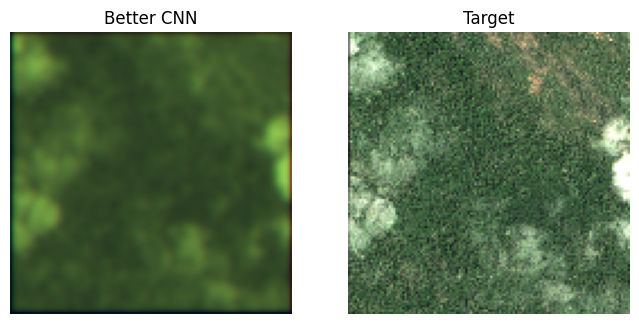

In [22]:
# Visualize Better CNN prediction

def show_better_prediction(index=0):
    better_cnn.eval()

    with torch.no_grad():
        pred = better_cnn(X_cnn[index:index+1])[0]
        target = Y_cnn[index]

    pred_img = pred.permute(1, 2, 0).numpy()
    target_img = target.permute(1, 2, 0).numpy()

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(pred_img)
    plt.title("Better CNN")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

    plt.show()

show_better_prediction(0)

In [23]:
def train_model(model, optimizer, X, Y, epochs=5):
    losses = []

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, Y)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

    return losses

In [24]:
# Train with SGD

model_sgd = BetterCNN()

optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01)

print("Training with SGD...\n")
loss_sgd = train_model(model_sgd, optimizer_sgd, X_cnn, Y_cnn, epochs=10)

Training with SGD...

Epoch [1/10], Loss: 0.125287
Epoch [2/10], Loss: 0.123452
Epoch [3/10], Loss: 0.121660
Epoch [4/10], Loss: 0.119914
Epoch [5/10], Loss: 0.118213
Epoch [6/10], Loss: 0.116558
Epoch [7/10], Loss: 0.114949
Epoch [8/10], Loss: 0.113387
Epoch [9/10], Loss: 0.111871
Epoch [10/10], Loss: 0.110399


In [25]:
# Train with Adam

model_adam = BetterCNN()

optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)

print("Training with Adam...\n")
loss_adam = train_model(model_adam, optimizer_adam, X_cnn, Y_cnn, epochs=10)

Training with Adam...

Epoch [1/10], Loss: 0.147156
Epoch [2/10], Loss: 0.131587
Epoch [3/10], Loss: 0.110076
Epoch [4/10], Loss: 0.077940
Epoch [5/10], Loss: 0.035977
Epoch [6/10], Loss: 0.019888
Epoch [7/10], Loss: 0.050390
Epoch [8/10], Loss: 0.026763
Epoch [9/10], Loss: 0.011913
Epoch [10/10], Loss: 0.014733


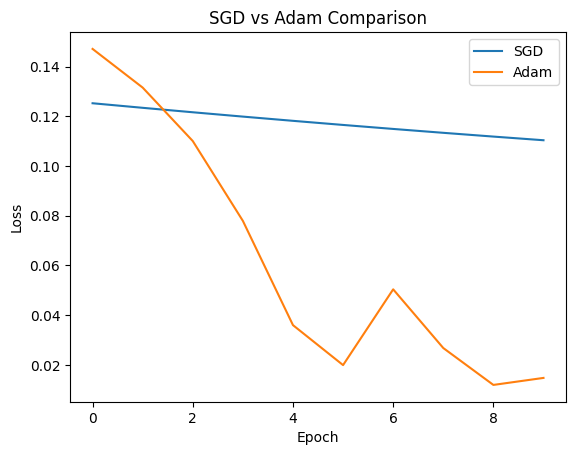

In [26]:
import matplotlib.pyplot as plt

plt.plot(loss_sgd, label="SGD")
plt.plot(loss_adam, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD vs Adam Comparison")
plt.legend()
plt.show()

In [27]:
# SGD with Momentum

model_momentum = BetterCNN()

optimizer_momentum = torch.optim.SGD(
    model_momentum.parameters(),
    lr=0.01,
    momentum=0.9
)

print("Training with SGD + Momentum...\n")
loss_momentum = train_model(model_momentum, optimizer_momentum, X_cnn, Y_cnn, epochs=10)

Training with SGD + Momentum...

Epoch [1/10], Loss: 0.135423
Epoch [2/10], Loss: 0.133773
Epoch [3/10], Loss: 0.130669
Epoch [4/10], Loss: 0.126312
Epoch [5/10], Loss: 0.120900
Epoch [6/10], Loss: 0.114636
Epoch [7/10], Loss: 0.107730
Epoch [8/10], Loss: 0.100389
Epoch [9/10], Loss: 0.092824
Epoch [10/10], Loss: 0.085193


In [28]:
# SGD with Nesterov

model_nesterov = BetterCNN()

optimizer_nesterov = torch.optim.SGD(
    model_nesterov.parameters(),
    lr=0.01,
    momentum=0.9,
    nesterov=True
)

print("Training with Nesterov...\n")
loss_nesterov = train_model(model_nesterov, optimizer_nesterov, X_cnn, Y_cnn, epochs=10)

Training with Nesterov...

Epoch [1/10], Loss: 0.131439
Epoch [2/10], Loss: 0.127088
Epoch [3/10], Loss: 0.121033
Epoch [4/10], Loss: 0.113652
Epoch [5/10], Loss: 0.105253
Epoch [6/10], Loss: 0.096111
Epoch [7/10], Loss: 0.086711
Epoch [8/10], Loss: 0.077276
Epoch [9/10], Loss: 0.067958
Epoch [10/10], Loss: 0.058590


In [29]:
# Adagrad optimizer

model_adagrad = BetterCNN()

optimizer_adagrad = torch.optim.Adagrad(
    model_adagrad.parameters(),
    lr=0.01
)

print("Training with Adagrad...\n")
loss_adagrad = train_model(model_adagrad, optimizer_adagrad, X_cnn, Y_cnn, epochs=10)

Training with Adagrad...

Epoch [1/10], Loss: 0.142868
Epoch [2/10], Loss: 58.608768
Epoch [3/10], Loss: 0.136930
Epoch [4/10], Loss: 0.134704
Epoch [5/10], Loss: 0.134297
Epoch [6/10], Loss: 0.132097
Epoch [7/10], Loss: 0.124828
Epoch [8/10], Loss: 0.112393
Epoch [9/10], Loss: 0.097573
Epoch [10/10], Loss: 0.082622


In [30]:
# RMSProp optimizer

model_rmsprop = BetterCNN()

optimizer_rmsprop = torch.optim.RMSprop(
    model_rmsprop.parameters(),
    lr=0.001
)

print("Training with RMSProp...\n")
loss_rmsprop = train_model(model_rmsprop, optimizer_rmsprop, X_cnn, Y_cnn, epochs=10)

Training with RMSProp...

Epoch [1/10], Loss: 0.106217
Epoch [2/10], Loss: 41.114132
Epoch [3/10], Loss: 0.119532
Epoch [4/10], Loss: 0.106375
Epoch [5/10], Loss: 0.100497
Epoch [6/10], Loss: 0.082729
Epoch [7/10], Loss: 0.035788
Epoch [8/10], Loss: 0.047075
Epoch [9/10], Loss: 0.056959
Epoch [10/10], Loss: 0.023711


In [31]:
# Adadelta optimizer

model_adadelta = BetterCNN()

optimizer_adadelta = torch.optim.Adadelta(
    model_adadelta.parameters(),
    lr=1.0
)

print("Training with Adadelta...\n")
loss_adadelta = train_model(model_adadelta, optimizer_adadelta, X_cnn, Y_cnn, epochs=10)

Training with Adadelta...

Epoch [1/10], Loss: 0.129599
Epoch [2/10], Loss: 0.119472
Epoch [3/10], Loss: 0.103316
Epoch [4/10], Loss: 0.058636
Epoch [5/10], Loss: 0.078076
Epoch [6/10], Loss: 0.098245
Epoch [7/10], Loss: 0.079231
Epoch [8/10], Loss: 0.044901
Epoch [9/10], Loss: 0.015486
Epoch [10/10], Loss: 0.015279


In [32]:
# L2 Regularization (weight decay)

model_l2 = BetterCNN()

optimizer_l2 = torch.optim.SGD(
    model_l2.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=0.001   # L2 term
)

print("Training with L2 Regularization...\n")
loss_l2 = train_model(model_l2, optimizer_l2, X_cnn, Y_cnn, epochs=10)

Training with L2 Regularization...

Epoch [1/10], Loss: 0.147380
Epoch [2/10], Loss: 0.145360
Epoch [3/10], Loss: 0.141600
Epoch [4/10], Loss: 0.136406
Epoch [5/10], Loss: 0.130086
Epoch [6/10], Loss: 0.122950
Epoch [7/10], Loss: 0.115307
Epoch [8/10], Loss: 0.107365
Epoch [9/10], Loss: 0.099260
Epoch [10/10], Loss: 0.091115


In [33]:
# CNN with Dropout

class CNN_Dropout(nn.Module):
    def __init__(self):
        super(CNN_Dropout, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(0.3),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(0.3),

            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 3, 3, padding=1)
        )

    def forward(self, x):
        return self.model(x)

model_dropout = CNN_Dropout()

optimizer_dropout = torch.optim.SGD(
    model_dropout.parameters(),
    lr=0.01,
    momentum=0.9
)

print("Training with Dropout...\n")
loss_dropout = train_model(model_dropout, optimizer_dropout, X_cnn, Y_cnn, epochs=10)

Training with Dropout...

Epoch [1/10], Loss: 0.153506
Epoch [2/10], Loss: 0.150667
Epoch [3/10], Loss: 0.144548
Epoch [4/10], Loss: 0.135561
Epoch [5/10], Loss: 0.125828
Epoch [6/10], Loss: 0.117020
Epoch [7/10], Loss: 0.103586
Epoch [8/10], Loss: 0.096092
Epoch [9/10], Loss: 0.085371
Epoch [10/10], Loss: 0.074225


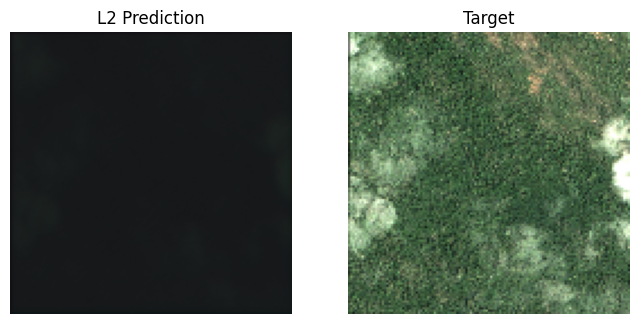

In [34]:
def show_l2_prediction(index=0):
    model_l2.eval()

    with torch.no_grad():
        pred = model_l2(X_cnn[index:index+1])[0]
        target = Y_cnn[index]

    pred_img = pred.permute(1, 2, 0).numpy()
    target_img = target.permute(1, 2, 0).numpy()

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(pred_img)
    plt.title("L2 Prediction")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

    plt.show()

show_l2_prediction(0)

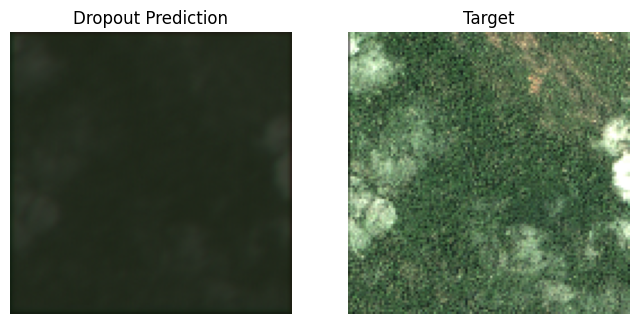

In [35]:
def show_dropout_prediction(index=0):
    model_dropout.eval()

    with torch.no_grad():
        pred = model_dropout(X_cnn[index:index+1])[0]
        target = Y_cnn[index]

    pred_img = pred.permute(1, 2, 0).numpy()
    target_img = target.permute(1, 2, 0).numpy()

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(pred_img)
    plt.title("Dropout Prediction")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

    plt.show()

show_dropout_prediction(0)

In [36]:
# Add noise to input
def add_noise(x, noise_level=0.1):
    noise = torch.randn_like(x) * noise_level
    return torch.clamp(x + noise, 0.0, 1.0)

# Model
model_noise = BetterCNN()

optimizer_noise = torch.optim.SGD(
    model_noise.parameters(),
    lr=0.01,
    momentum=0.9
)

print("Training with Noise Injection...\n")

loss_noise = []

for epoch in range(10):
    model_noise.train()

    optimizer_noise.zero_grad()

    noisy_input = add_noise(X_cnn, 0.1)

    outputs = model_noise(noisy_input)
    loss = criterion(outputs, Y_cnn)

    loss.backward()
    optimizer_noise.step()

    loss_noise.append(loss.item())
    print(f"Epoch [{epoch+1}/10], Loss: {loss.item():.6f}")

Training with Noise Injection...

Epoch [1/10], Loss: 0.110962
Epoch [2/10], Loss: 0.109432
Epoch [3/10], Loss: 0.106551
Epoch [4/10], Loss: 0.102523
Epoch [5/10], Loss: 0.097570
Epoch [6/10], Loss: 0.091901
Epoch [7/10], Loss: 0.085718
Epoch [8/10], Loss: 0.079208
Epoch [9/10], Loss: 0.072539
Epoch [10/10], Loss: 0.065881


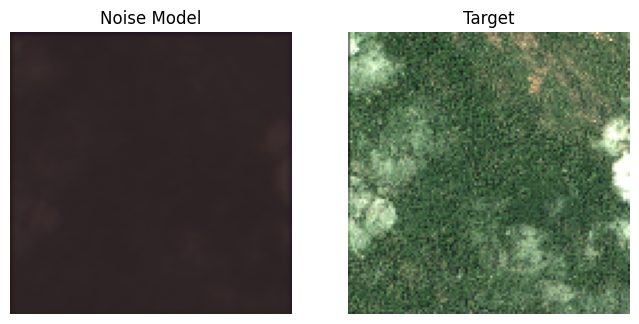

In [37]:
def show_noise_prediction(index=0):
    model_noise.eval()

    with torch.no_grad():
        noisy_input = add_noise(X_cnn[index:index+1], 0.1)
        pred = model_noise(noisy_input)[0]
        target = Y_cnn[index]

    pred_img = pred.permute(1, 2, 0).numpy()
    target_img = target.permute(1, 2, 0).numpy()

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(pred_img)
    plt.title("Noise Model")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

    plt.show()

show_noise_prediction(0)

In [38]:
import torchvision.models as models

# Load pretrained VGG
vgg = models.vgg16(pretrained=True)

print(vgg)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [39]:
class VGGFeatureCNN(nn.Module):
    def __init__(self):
        super(VGGFeatureCNN, self).__init__()

        # Use only feature extractor
        self.features = vgg.features[:10]  # first few layers

        # Freeze VGG layers
        for param in self.features.parameters():
            param.requires_grad = False

        # Custom layers
        self.recon = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.recon(x)
        return x

model_vgg = VGGFeatureCNN()

optimizer_vgg = torch.optim.SGD(
    model_vgg.parameters(),
    lr=0.01,
    momentum=0.9
)

print(model_vgg)

VGGFeatureCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (recon): Sequential(
    (0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)


In [40]:
class VGGFeatureCNN(nn.Module):
    def __init__(self):
        super(VGGFeatureCNN, self).__init__()

        self.features = vgg.features[:10]

        for param in self.features.parameters():
            param.requires_grad = False

        self.recon = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),

            # Upsample back to original size
            nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False),

            nn.Conv2d(32, 3, 3, padding=1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.recon(x)
        return x

model_vgg = VGGFeatureCNN()

optimizer_vgg = torch.optim.SGD(
    model_vgg.parameters(),
    lr=0.01,
    momentum=0.9
)

print("Fixed VGG model ready")

Fixed VGG model ready


In [43]:
class VGGFeatureCNN(nn.Module):
    def __init__(self):
        super(VGGFeatureCNN, self).__init__()

        self.features = vgg.features[:10]

        for param in self.features.parameters():
            param.requires_grad = False

        self.recon = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1)
        )

    def forward(self, x):
        x = self.features(x)

        # Force exact size match
        x = nn.functional.interpolate(x, size=(125, 125), mode='bilinear', align_corners=False)

        x = self.recon(x)
        return x

model_vgg = VGGFeatureCNN()

# 🔥 Changed optimizer to Adam
optimizer_vgg = torch.optim.Adam(
    model_vgg.parameters(),
    lr=0.001
)

print("Fixed VGG size mismatch")

Fixed VGG size mismatch


In [44]:
loss_vgg = train_model(model_vgg, optimizer_vgg, X_cnn, Y_cnn, epochs=10)

Epoch [1/10], Loss: 0.202514
Epoch [2/10], Loss: 0.037423
Epoch [3/10], Loss: 0.050186
Epoch [4/10], Loss: 0.038800
Epoch [5/10], Loss: 0.032423
Epoch [6/10], Loss: 0.030690
Epoch [7/10], Loss: 0.032085
Epoch [8/10], Loss: 0.024364
Epoch [9/10], Loss: 0.024844
Epoch [10/10], Loss: 0.025033


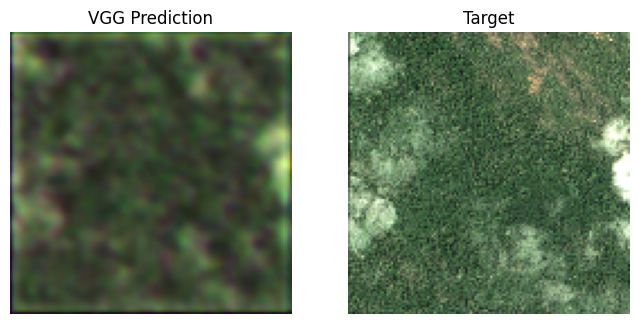

In [45]:
def show_vgg_prediction(index=0):
    model_vgg.eval()

    with torch.no_grad():
        pred = model_vgg(X_cnn[index:index+1])[0]
        target = Y_cnn[index]

    pred_img = pred.permute(1, 2, 0).numpy()
    target_img = target.permute(1, 2, 0).numpy()

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(pred_img)
    plt.title("VGG Prediction")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

    plt.show()

show_vgg_prediction(0)

In [46]:
import torchvision.models as models

resnet = models.resnet18(pretrained=True)

class ResNetFeatureCNN(nn.Module):
    def __init__(self):
        super(ResNetFeatureCNN, self).__init__()

        # Use initial layers only
        self.features = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1
        )

        # Freeze pretrained layers
        for param in self.features.parameters():
            param.requires_grad = False

        # Reconstruction layers
        self.recon = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),

            nn.Upsample(size=(125,125), mode='bilinear', align_corners=False),

            nn.Conv2d(32, 3, 3, padding=1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.recon(x)
        return x

model_resnet = ResNetFeatureCNN()

# 🔥 Changed optimizer to Adam
optimizer_resnet = torch.optim.Adam(
    model_resnet.parameters(),
    lr=0.001
)

print("ResNet model ready")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet model ready


In [47]:
print("Training ResNet-based model...\n")

loss_resnet = train_model(model_resnet, optimizer_resnet, X_cnn, Y_cnn, epochs=10)

Training ResNet-based model...

Epoch [1/10], Loss: 0.074187
Epoch [2/10], Loss: 0.074066
Epoch [3/10], Loss: 0.052720
Epoch [4/10], Loss: 0.035489
Epoch [5/10], Loss: 0.038137
Epoch [6/10], Loss: 0.039488
Epoch [7/10], Loss: 0.034788
Epoch [8/10], Loss: 0.029720
Epoch [9/10], Loss: 0.025646
Epoch [10/10], Loss: 0.023797


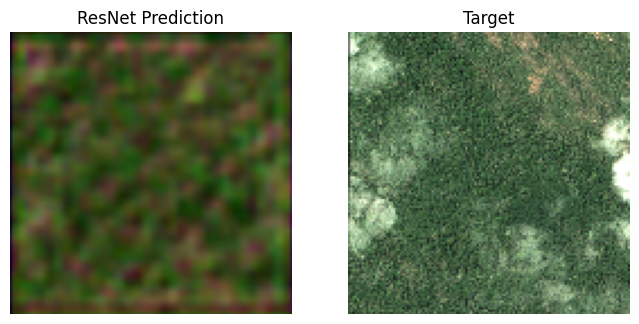

In [48]:
def show_resnet_prediction(index=0):
    model_resnet.eval()

    with torch.no_grad():
        pred = model_resnet(X_cnn[index:index+1])[0]
        target = Y_cnn[index]

    pred_img = pred.permute(1, 2, 0).numpy()
    target_img = target.permute(1, 2, 0).numpy()

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(pred_img)
    plt.title("ResNet Prediction")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

    plt.show()

show_resnet_prediction(0)

In [49]:
alexnet = models.alexnet(pretrained=True)

class AlexNetCNN(nn.Module):
    def __init__(self):
        super(AlexNetCNN, self).__init__()

        self.features = alexnet.features[:6]  # early layers

        for param in self.features.parameters():
            param.requires_grad = False

        self.recon = nn.Sequential(
            nn.Conv2d(192, 64, 3, padding=1),
            nn.ReLU(),

            nn.Upsample(size=(125,125), mode='bilinear', align_corners=False),

            nn.Conv2d(64, 3, 3, padding=1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.recon(x)
        return x

model_alex = AlexNetCNN()

# 🔥 Changed optimizer to Adam
optimizer_alex = torch.optim.Adam(
    model_alex.parameters(),
    lr=0.001
)

print("AlexNet model ready")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


AlexNet model ready


In [50]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class SRResNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.entry = nn.Conv2d(3, 64, 3, padding=1)

        self.resblocks = nn.Sequential(
            *[ResidualBlock(64) for _ in range(5)]
        )

        self.exit = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1)
        )

    def forward(self, x):
        x = self.entry(x)
        x = self.resblocks(x)
        x = self.exit(x)
        return x

model_srresnet = SRResNet()

optimizer_srresnet = torch.optim.Adam(
    model_srresnet.parameters(),
    lr=0.001
)

print("SRResNet ready")

SRResNet ready


In [51]:
print("Training AlexNet...\n")
loss_alex = train_model(model_alex, optimizer_alex, X_cnn, Y_cnn, epochs=10)


print("\nTraining SRResNet...\n")
loss_srresnet = train_model(model_srresnet, optimizer_srresnet, X_cnn, Y_cnn, epochs=10)

Training AlexNet...

Epoch [1/10], Loss: 0.153534
Epoch [2/10], Loss: 0.527733
Epoch [3/10], Loss: 0.047319
Epoch [4/10], Loss: 0.073159
Epoch [5/10], Loss: 0.102364
Epoch [6/10], Loss: 0.111582
Epoch [7/10], Loss: 0.112743
Epoch [8/10], Loss: 0.110059
Epoch [9/10], Loss: 0.104702
Epoch [10/10], Loss: 0.097101

Training SRResNet...

Epoch [1/10], Loss: 0.107806
Epoch [2/10], Loss: 0.036591
Epoch [3/10], Loss: 0.036273
Epoch [4/10], Loss: 0.028301
Epoch [5/10], Loss: 0.015464
Epoch [6/10], Loss: 0.019459
Epoch [7/10], Loss: 0.011119
Epoch [8/10], Loss: 0.010389
Epoch [9/10], Loss: 0.012143
Epoch [10/10], Loss: 0.010976


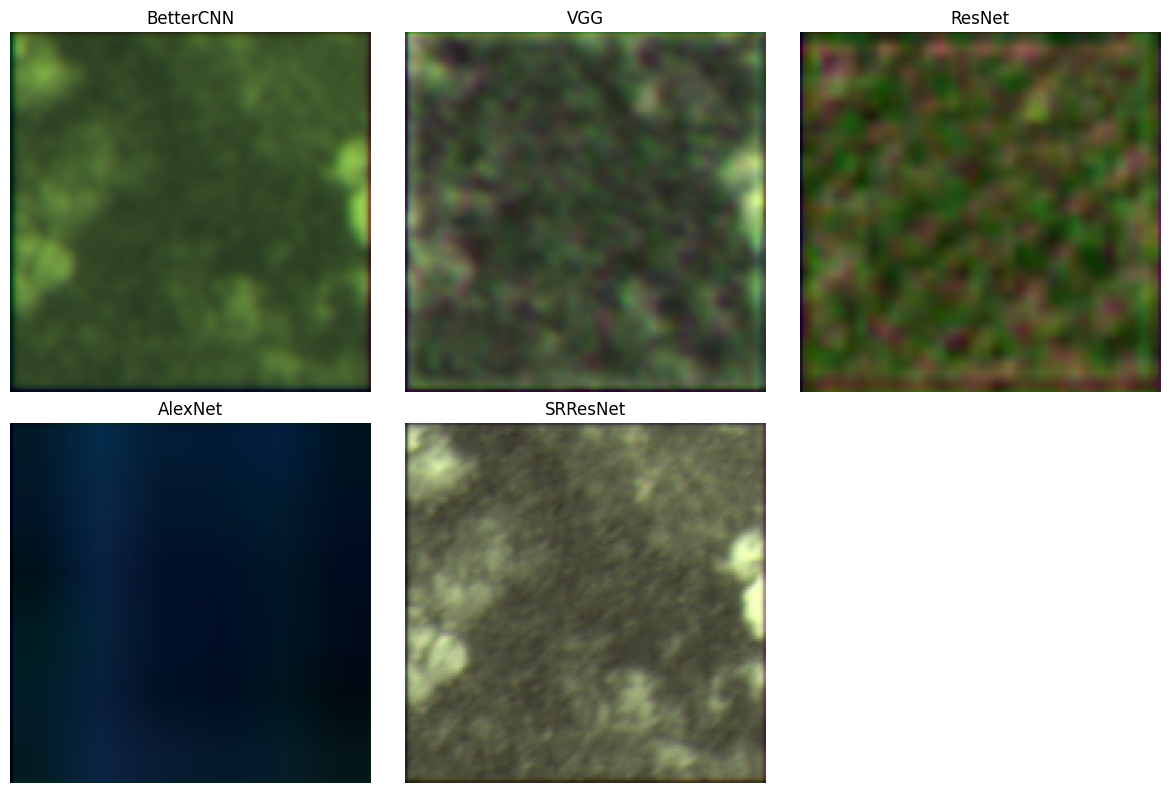

In [52]:
def compare_models(index=0):
    models_list = [
        ("BetterCNN", better_cnn),
        ("VGG", model_vgg),
        ("ResNet", model_resnet),
        ("AlexNet", model_alex),
        ("SRResNet", model_srresnet)
    ]

    plt.figure(figsize=(12,8))

    for i, (name, model) in enumerate(models_list):
        model.eval()

        with torch.no_grad():
            pred = model(X_cnn[index:index+1])[0]

        pred_img = pred.permute(1, 2, 0).numpy()

        plt.subplot(2,3,i+1)
        plt.imshow(pred_img)
        plt.title(name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

compare_models(0)

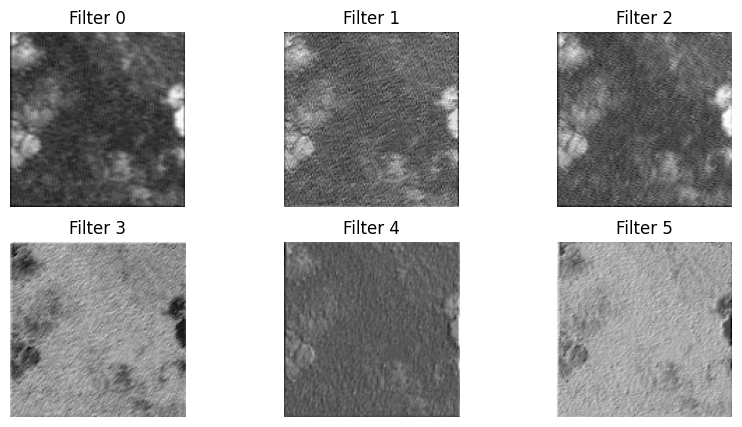

In [53]:
# Visualize feature maps after first conv layer

def visualize_conv(model, index=0):
    model.eval()

    # get first conv layer
    first_conv = model.model[0]

    with torch.no_grad():
        x = X_cnn[index:index+1]
        features = first_conv(x)[0]  # remove batch

    # show first 6 feature maps
    plt.figure(figsize=(10,5))

    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(features[i].cpu().numpy(), cmap='gray')
        plt.title(f"Filter {i}")
        plt.axis("off")

    plt.show()

visualize_conv(better_cnn, 0)

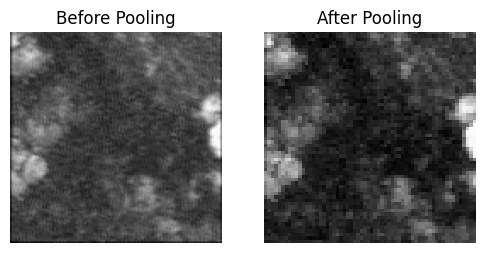

In [54]:
pool = nn.MaxPool2d(2)

def visualize_pooling(index=0):
    x = X_cnn[index:index+1]

    with torch.no_grad():
        conv_out = better_cnn.model[0](x)
        pooled = pool(conv_out)

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(conv_out[0][0].cpu().numpy(), cmap='gray')
    plt.title("Before Pooling")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pooled[0][0].cpu().numpy(), cmap='gray')
    plt.title("After Pooling")
    plt.axis("off")

    plt.show()

visualize_pooling(0)

In [57]:
class GuidedReLUFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return torch.relu(input)

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad_input = grad_output.clone()

        grad_input[input < 0] = 0
        grad_input[grad_output < 0] = 0

        return grad_input


class GuidedReLU(nn.Module):
    def forward(self, x):
        return GuidedReLUFunction.apply(x)


def replace_relu(module):
    for name, layer in module.named_children():
        if isinstance(layer, nn.ReLU):
            setattr(module, name, GuidedReLU())
        else:
            replace_relu(layer)


guided_model = BetterCNN()
guided_model.load_state_dict(better_cnn.state_dict())

replace_relu(guided_model)

print("Guided model ready")

Guided model ready


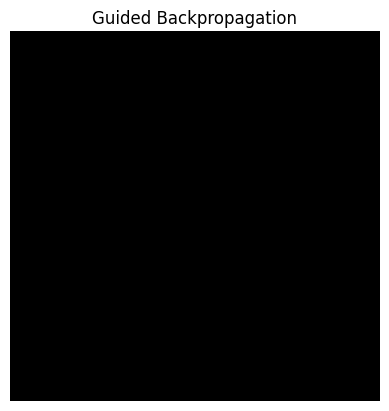

In [58]:
def guided_backprop(model, input_img):
    input_img = input_img.clone().requires_grad_(True)

    output = model(input_img)
    loss = output.mean()

    loss.backward()

    grad = input_img.grad[0]
    grad = grad.permute(1, 2, 0).detach().numpy()

    return grad


grad_img = guided_backprop(guided_model, X_cnn[0:1])

plt.imshow(grad_img)
plt.title("Guided Backpropagation")
plt.axis("off")
plt.show()

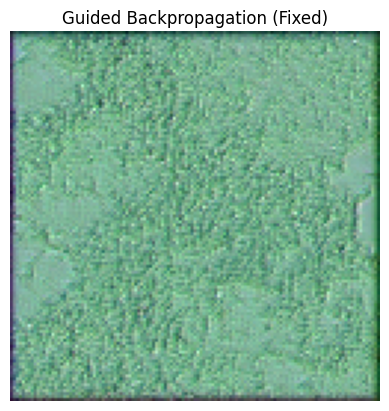

In [59]:
def guided_backprop(model, input_img):
    input_img = input_img.clone().requires_grad_(True)

    output = model(input_img)

    # Focus on one channel (important fix)
    loss = output[0, 0].mean()

    loss.backward()

    grad = input_img.grad[0]
    grad = grad.permute(1, 2, 0).detach().numpy()

    # Normalize for visibility
    grad = (grad - grad.min()) / (grad.max() - grad.min() + 1e-8)

    return grad


grad_img = guided_backprop(guided_model, X_cnn[0:1])

plt.imshow(grad_img)
plt.title("Guided Backpropagation (Fixed)")
plt.axis("off")
plt.show()

In [62]:
class UndercompleteAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(16, 3, 3, padding=1)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)

        # 🔥 FIX: force exact size
        x = nn.functional.interpolate(x, size=(125,125), mode='bilinear', align_corners=False)

        return x


model_under = UndercompleteAE()
opt_under = torch.optim.Adam(model_under.parameters(), lr=0.001)

print("Fixed Undercomplete AE ready")

Fixed Undercomplete AE ready


In [63]:
loss_under = train_model(model_under, opt_under, X_cnn, Y_cnn, epochs=10)

Epoch [1/10], Loss: 0.139539
Epoch [2/10], Loss: 0.135300
Epoch [3/10], Loss: 0.131107
Epoch [4/10], Loss: 0.127094
Epoch [5/10], Loss: 0.123014
Epoch [6/10], Loss: 0.118455
Epoch [7/10], Loss: 0.113288
Epoch [8/10], Loss: 0.107423
Epoch [9/10], Loss: 0.100786
Epoch [10/10], Loss: 0.093352


In [64]:
class OvercompleteAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, 3, padding=1)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


model_over = OvercompleteAE()
opt_over = torch.optim.Adam(model_over.parameters(), lr=0.001)

print("Overcomplete AE ready")

Overcomplete AE ready


In [65]:
loss_over = train_model(model_over, opt_over, X_cnn, Y_cnn, epochs=10)

Epoch [1/10], Loss: 0.138183
Epoch [2/10], Loss: 0.082116
Epoch [3/10], Loss: 0.025818
Epoch [4/10], Loss: 0.061372
Epoch [5/10], Loss: 0.026657
Epoch [6/10], Loss: 0.014446
Epoch [7/10], Loss: 0.022433
Epoch [8/10], Loss: 0.027986
Epoch [9/10], Loss: 0.026333
Epoch [10/10], Loss: 0.019487


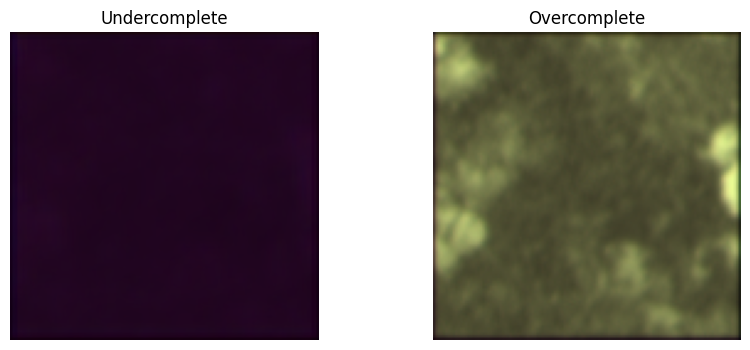

In [66]:
def compare_autoencoders(index=0):
    models_list = [
        ("Undercomplete", model_under),
        ("Overcomplete", model_over)
    ]

    plt.figure(figsize=(10,4))

    for i, (name, model) in enumerate(models_list):
        model.eval()

        with torch.no_grad():
            pred = model(X_cnn[index:index+1])[0]

        pred_img = pred.permute(1,2,0).numpy()

        plt.subplot(1,2,i+1)
        plt.imshow(pred_img)
        plt.title(name)
        plt.axis("off")

    plt.show()

compare_autoencoders(0)